# PoroTomo DTSv — Brady Hot Springs vertical DTS (March 2016, ~8 days)

Distributed temperature sensing along a fiber-optic cable in Brady Hot Springs observation well 56-1, processed and split into the down-going (`Forward Length`) and up-going (`Backward Length`) legs of the borehole. Sampling is ~12.7 cm in depth and ~62 s in time over ~8 days, giving a 2935 × 11235 = ~33M-point grid for the down-going leg.

This notebook fits an EFGP regression with an isotropic SE kernel — only demeaning and [0,1]-normalizing the inputs, with no polynomial detrending of the geothermal gradient.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
import sys
sys.path.append('..')
from efgpnd import EFGPND
from load_porotomo_dtsv import load_porotomo_dtsv_grid, load_porotomo_dtsv_torch

In [2]:
z, t, T_grid, meta = load_porotomo_dtsv_grid(leg='forward')
print(f"shape (n_z, n_t): {T_grid.shape}")
print(f"depth range: {z.min():.2f} to {z.max():.2f} m  (step {meta['z_step_m']:.3f} m)")
print(f"time range: 0 to {t.max()/86400:.2f} days  (step {meta['t_step_s']:.1f} s)")
print(f"temperature range: {T_grid.min():.2f} to {T_grid.max():.2f} \u00b0C; mean {T_grid.mean():.2f}")
print(f"start datetime: {meta['start_datetime']}")

shape (n_z, n_t): (2935, 11235)
depth range: 0.10 to 371.22 m  (step 0.127 m)
time range: 0 to 8.07 days  (step 62.0 s)
temperature range: -5.67 to 162.50 °C; mean 122.35
start datetime: 2016-03-17 23:25:20


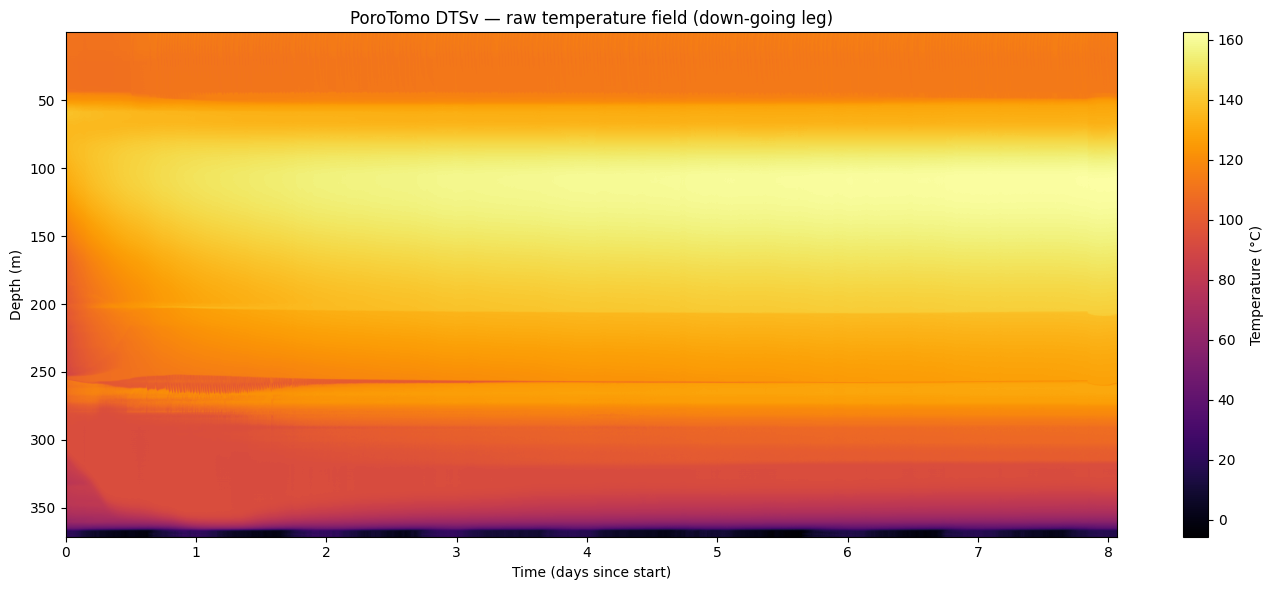

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(T_grid, aspect='auto', origin='lower',
               extent=[0, t.max()/86400, z.max(), z.min()],
               cmap='inferno')
ax.set_xlabel('Time (days since start)')
ax.set_ylabel('Depth (m)')
ax.set_title('PoroTomo DTSv — raw temperature field (down-going leg)')
plt.colorbar(im, ax=ax, label='Temperature (\u00b0C)')
plt.tight_layout()

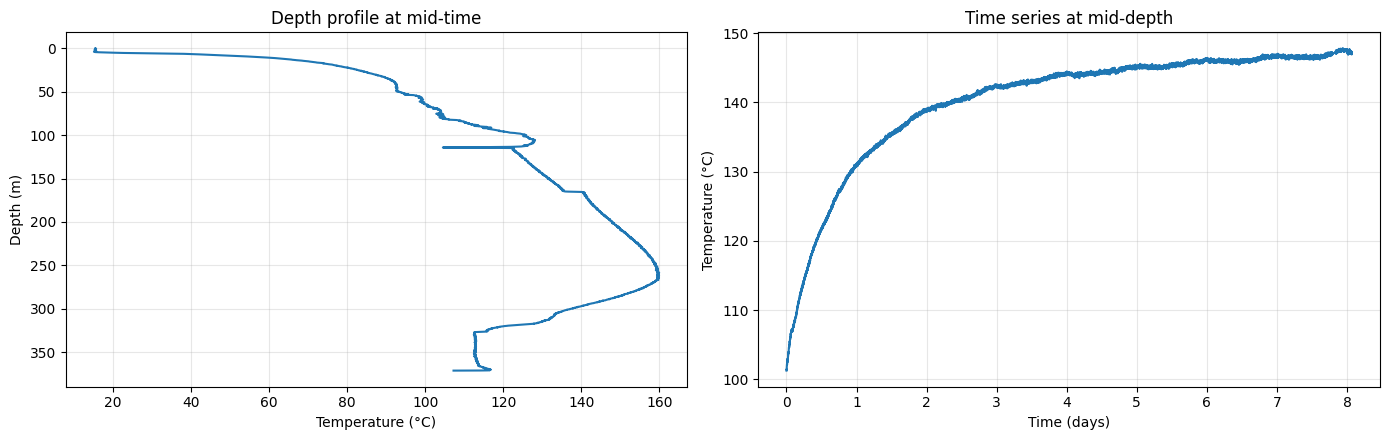

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(T_grid[:, T_grid.shape[1]//2], z)
ax1.invert_yaxis()
ax1.set_xlabel('Temperature (\u00b0C)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Depth profile at mid-time')
ax1.grid(alpha=0.3)

ax2.plot(t/86400, T_grid[T_grid.shape[0]//2, :])
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Temperature (\u00b0C)')
ax2.set_title('Time series at mid-depth')
ax2.grid(alpha=0.3)
plt.tight_layout()

In [5]:
x, y, _ = load_porotomo_dtsv_torch(leg='forward')
print(f"x shape: {x.shape}")  # (N, 2) - depth, time
print(f"y shape: {y.shape}")  # (N,) - temperature (°C)
print(f"depth range: {x[:,0].min():.2f} to {x[:,0].max():.2f} m")
print(f"time range: {x[:,1].min():.2f} to {x[:,1].max():.2f} s")
print(f"temp range: {y.min():.2f} to {y.max():.2f} °C")

x shape: torch.Size([32974725, 2])
y shape: torch.Size([32974725])
depth range: 0.10 to 371.22 m
time range: 0.00 to 697099.00 s
temp range: -5.67 to 162.50 °C


In [6]:
# Normalize inputs to [0, 1] and standardize outputs (no detrending)
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f"x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}")
print(f"y mean={y.mean():.4f}, std={y.std():.4f}")

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=-0.0000, std=1.0000


In [7]:
x = x.to(dtype=torch.float32)
y = y.to(dtype=torch.float32)

In [8]:
EPSILON = 1e-3
kernel_type = 'SquaredExponential'
cg_tol = 1e-4
noise_floor = 1e-4

In [9]:
max_iters = 100
J = 1

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
    'mean_cg_iters': [],
    'trace_cg_iters': [],
    'mtot': [],
    'feature_count': [],
}

model = EFGPND(x, y, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.4)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor)
    optimizer.step()

    s = model.last_gradient_stats
    lengthscale = model.kernel.get_hyper('lengthscale')
    variance    = model.kernel.get_hyper('variance')
    sigmasq     = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(s.get('mean_cg_iters'))
    training_log['trace_cg_iters'].append(s.get('trace_cg_iters'))
    training_log['mtot'].append(s.get('mtot'))
    training_log['feature_count'].append(s.get('feature_count'))

    if it % 5 == 0:
        print(f"iter {it:>3}  \u2113={lengthscale:.4g}  \u03c3_f\u00b2={variance:.4g}  \u03c3_n\u00b2={sigmasq:.4g}  "
              f"cg(mean/trace)={s.get('mean_cg_iters')}/{s.get('trace_cg_iters')}  "
              f"mtot={s.get('mtot')}  M={s.get('feature_count')}")

print(f"Final: \u2113={lengthscale:.4g}, \u03c3_f\u00b2={variance:.4g}, \u03c3_n\u00b2={sigmasq:.4g}")

iter   0  ℓ=0.1809  σ_f²=1.271  σ_n²=0.1384  cg(mean/trace)=2/2  mtot=11  M=121
iter   5  ℓ=0.05347  σ_f²=2.213  σ_n²=0.01991  cg(mean/trace)=3/2  mtot=27  M=729


KeyboardInterrupt: 

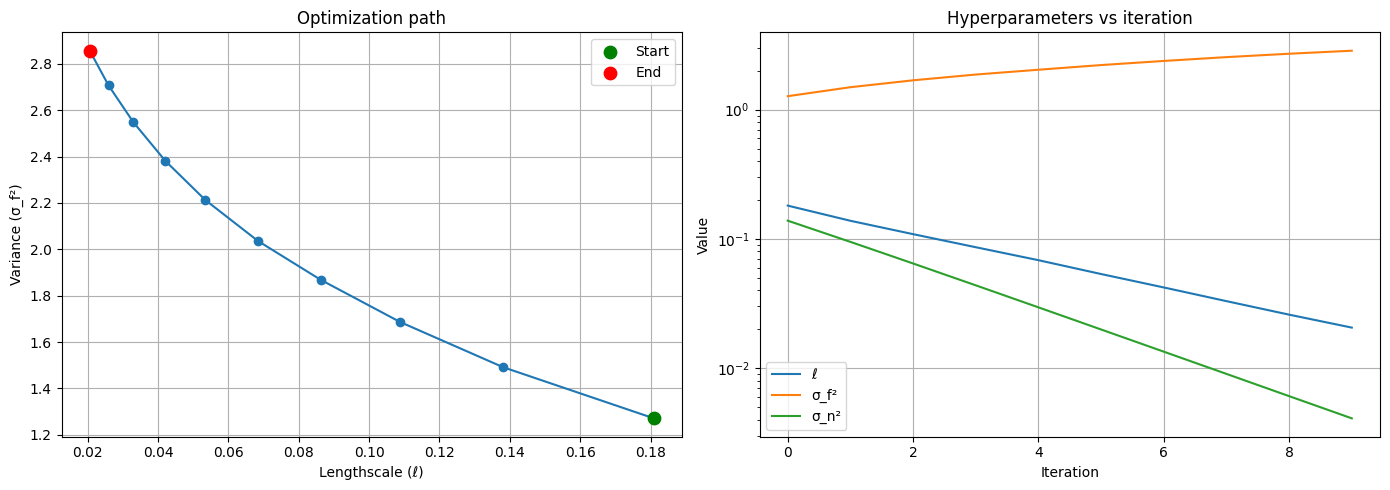

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (\u2113)')
ax1.set_ylabel('Variance (\u03c3_f\u00b2)')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='\u2113')
ax2.plot(training_log['iter'], training_log['variance'], label='\u03c3_f\u00b2')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='\u03c3_n\u00b2')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_yscale('log')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [14]:
n_z_pred, n_t_pred = 256, 256
g_z = torch.linspace(0, 1, n_z_pred, dtype=x.dtype)
g_t = torch.linspace(0, 1, n_t_pred, dtype=x.dtype)
GZ, GT = torch.meshgrid(g_z, g_t, indexing='ij')
x_new = torch.stack([GZ.flatten(), GT.flatten()], dim=1)

mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred

mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(n_z_pred, n_t_pred)
z_pred = (g_z.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item())
t_pred = (g_t.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item())

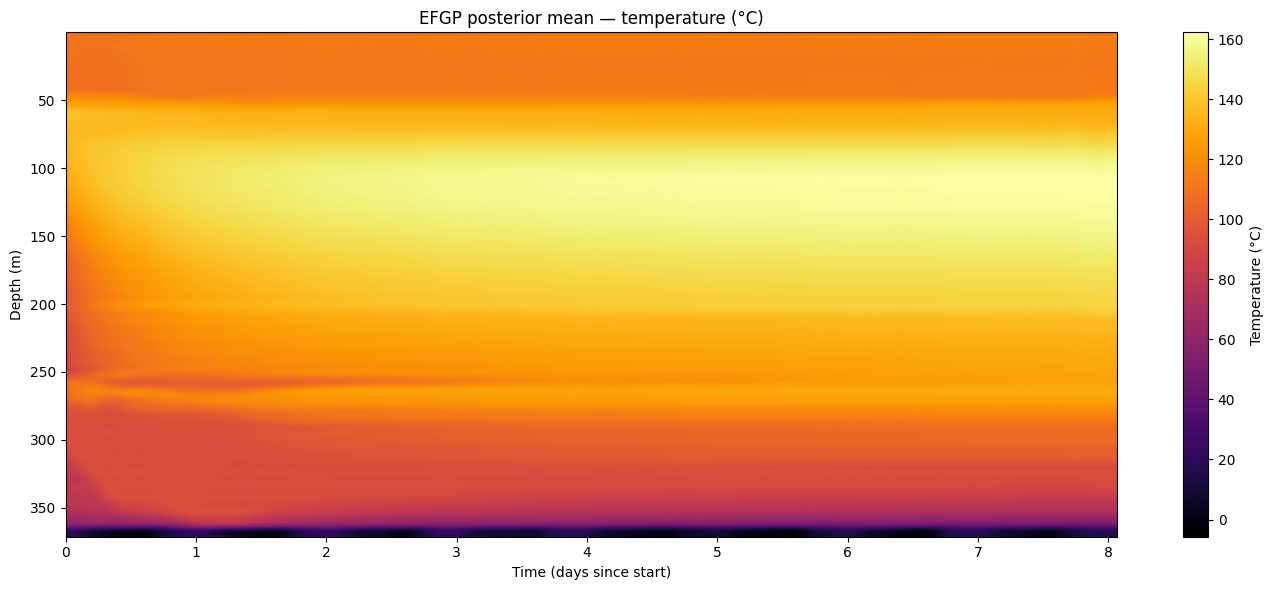

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(mean_grid, aspect='auto', origin='lower',
               extent=[t_pred.min()/86400, t_pred.max()/86400, z_pred.max(), z_pred.min()],
               cmap='inferno')
ax.set_xlabel('Time (days since start)')
ax.set_ylabel('Depth (m)')
ax.set_title('EFGP posterior mean — temperature (°C)')
plt.colorbar(im, ax=ax, label='Temperature (°C)')
plt.tight_layout()

## ARD: per-dim lengthscales for depth vs time

The isotropic run above collapses ℓ toward zero and inflates σ_f² — the
classic "single ℓ can't fit two scales at once" pathology. Here we re-run
with `ARDSquaredExponential` so depth and time get their own lengthscales.
The isotropic SE result is preserved as `model` / `training_log`; ARD goes
into `model_ard` / `training_log_ard`.

In [11]:
from kernels import ARDSquaredExponential

ker_ard = ARDSquaredExponential(
    dimension=x.shape[1],
    init_lengthscales=[0.1, 0.1],   # one per dim; a single float would broadcast
    init_variance=1.0,
)
model_ard = EFGPND(x, y, kernel=ker_ard, eps=EPSILON)
optimizer_ard = Adam(model_ard.parameters(), lr=0.5)

training_log_ard = {
    'iter': [],
    'lengthscales': [],   # list of [ℓ_z, ℓ_t] per iter
    'variance': [],
    'sigmasq': [],
    'mean_cg_iters': [],
    'trace_cg_iters': [],
    'mtot_per_dim': [],
    'feature_count': [],
}

for it in range(max_iters):
    optimizer_ard.zero_grad()
    model_ard.compute_gradients(trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor)
    optimizer_ard.step()

    s = model_ard.last_gradient_stats
    ls_now  = model_ard.kernel.lengthscales.tolist()
    var_now = model_ard.kernel.get_hyper('variance')
    sn_now  = model_ard._gp_params.sig2.item()
    training_log_ard['iter'].append(it)
    training_log_ard['lengthscales'].append(ls_now)
    training_log_ard['variance'].append(var_now)
    training_log_ard['sigmasq'].append(sn_now)
    training_log_ard['mean_cg_iters'].append(s.get('mean_cg_iters'))
    training_log_ard['trace_cg_iters'].append(s.get('trace_cg_iters'))
    training_log_ard['mtot_per_dim'].append(s.get('mtot_per_dim'))
    training_log_ard['feature_count'].append(s.get('feature_count'))

    if it % 5 == 0:
        ls_str = ", ".join(f"{l:.4g}" for l in ls_now)
        print(f"iter {it:>3}  ℓ=[{ls_str}]  σ_f²={var_now:.4g}  σ_n²={sn_now:.4g}  "
              f"cg(m/t)={s.get('mean_cg_iters')}/{s.get('trace_cg_iters')}  "
              f"mtot={s.get('mtot_per_dim')}  M={s.get('feature_count')}")

print(f"\nFinal ARD: ℓ={model_ard.kernel.lengthscales.tolist()}, "
      f"σ_f²={model_ard.kernel.get_hyper('variance'):.4g}, "
      f"σ_n²={model_ard._gp_params.sig2.item():.4g}")

iter   0  ℓ=[0.1621, 0.3908]  σ_f²=1.344  σ_n²=0.126  cg(m/t)=3/2  mtot=(11, 11)  M=121
iter   5  ℓ=[0.04657, 0.1529]  σ_f²=2.587  σ_n²=0.01109  cg(m/t)=2/2  mtot=(27, 13)  M=351
iter  10  ℓ=[0.0205, 0.02243]  σ_f²=3.659  σ_n²=0.001101  cg(m/t)=1/2  mtot=(57, 45)  M=2565
iter  15  ℓ=[0.01214, 0.007045]  σ_f²=4.355  σ_n²=0.0004366  cg(m/t)=1/2  mtot=(97, 149)  M=14453
iter  20  ℓ=[0.009629, 0.004973]  σ_f²=4.771  σ_n²=0.0006314  cg(m/t)=1/2  mtot=(127, 243)  M=30861
iter  25  ℓ=[0.01047, 0.006581]  σ_f²=4.918  σ_n²=0.0006783  cg(m/t)=1/2  mtot=(123, 203)  M=24969
iter  30  ℓ=[0.01302, 0.0116]  σ_f²=4.94  σ_n²=0.0006106  cg(m/t)=1/2  mtot=(101, 123)  M=12423
iter  35  ℓ=[0.01532, 0.02117]  σ_f²=4.975  σ_n²=0.0008202  cg(m/t)=1/2  mtot=(87, 69)  M=6003
iter  40  ℓ=[0.01642, 0.03404]  σ_f²=5.036  σ_n²=0.001143  cg(m/t)=1/2  mtot=(79, 45)  M=3555
iter  45  ℓ=[0.01629, 0.04562]  σ_f²=5.114  σ_n²=0.001054  cg(m/t)=1/2  mtot=(79, 33)  M=2607
iter  50  ℓ=[0.01505, 0.05078]  σ_f²=5.21  σ_n²=0.00

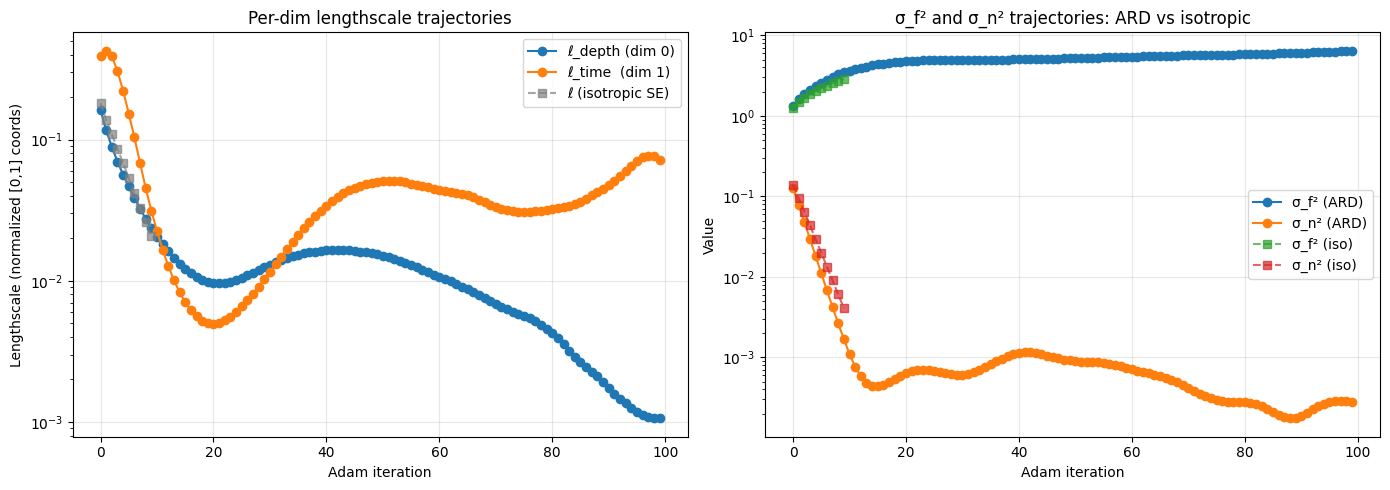

In [12]:
import numpy as np

ls_arr = np.array(training_log_ard['lengthscales'])  # (max_iters, d)
iters = np.array(training_log_ard['iter'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-dim lengthscale trajectories: depth (col 0) and time (col 1)
axes[0].plot(iters, ls_arr[:, 0], 'o-', label='ℓ_depth (dim 0)')
axes[0].plot(iters, ls_arr[:, 1], 'o-', label='ℓ_time  (dim 1)')
axes[0].plot(training_log['iter'], training_log['lengthscale'], 's--',
             color='gray', alpha=0.7, label='ℓ (isotropic SE)')
axes[0].set_xlabel('Adam iteration')
axes[0].set_ylabel('Lengthscale (normalized [0,1] coords)')
axes[0].set_yscale('log')
axes[0].set_title('Per-dim lengthscale trajectories')
axes[0].legend()
axes[0].grid(alpha=0.3)

# σ_f² and σ_n² trajectories: ARD vs iso
axes[1].plot(iters, training_log_ard['variance'], 'o-', label='σ_f² (ARD)')
axes[1].plot(iters, training_log_ard['sigmasq'],  'o-', label='σ_n² (ARD)')
axes[1].plot(training_log['iter'], training_log['variance'], 's--', alpha=0.7, label='σ_f² (iso)')
axes[1].plot(training_log['iter'], training_log['sigmasq'],  's--', alpha=0.7, label='σ_n² (iso)')
axes[1].set_xlabel('Adam iteration')
axes[1].set_ylabel('Value')
axes[1].set_yscale('log')
axes[1].set_title('σ_f² and σ_n² trajectories: ARD vs isotropic')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

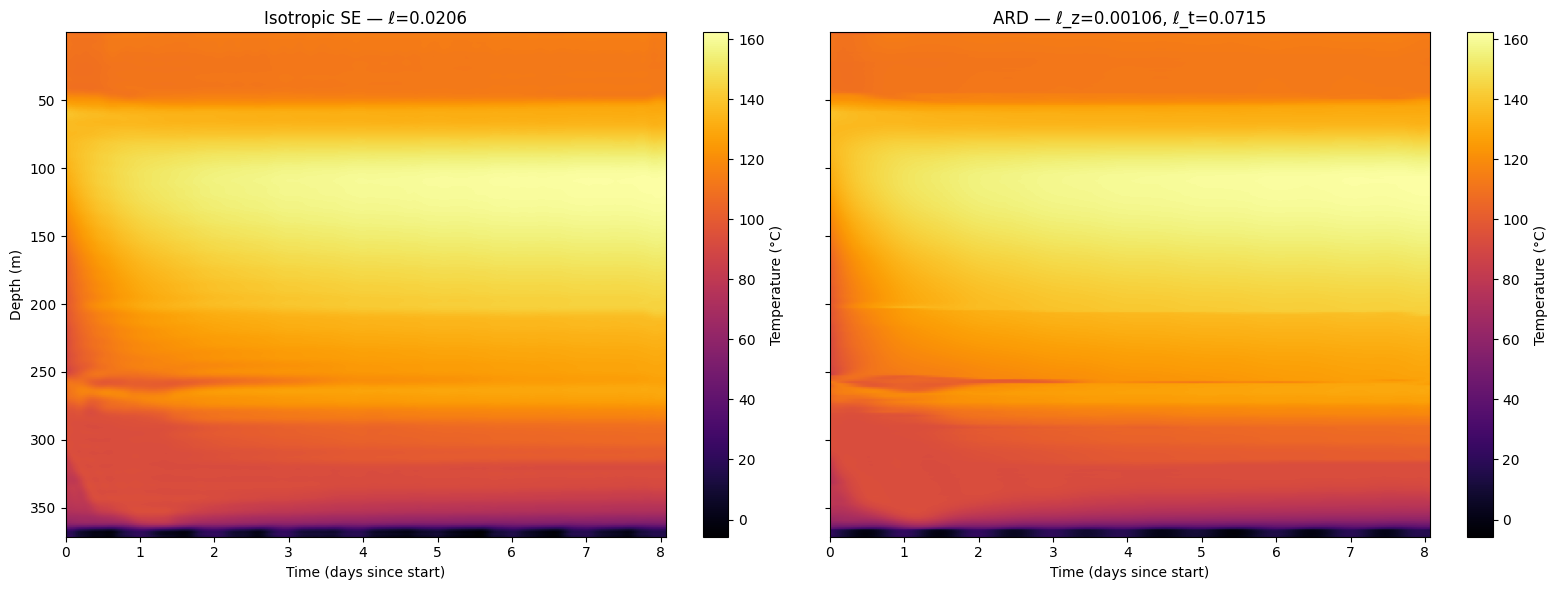

In [16]:
# Posterior mean from the ARD model on the same prediction grid as before
mean_pred_ard = model_ard.predict(x_new=x_new, return_variance=False)
mean_pred_ard = mean_pred_ard[0] if isinstance(mean_pred_ard, tuple) else mean_pred_ard
mean_grid_ard = (mean_pred_ard.detach().cpu() * y_std + y_mean).numpy().reshape(n_z_pred, n_t_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
vmin = min(mean_grid.min(), mean_grid_ard.min())
vmax = max(mean_grid.max(), mean_grid_ard.max())

im0 = axes[0].imshow(mean_grid, aspect='auto', origin='lower',
                     extent=[t_pred.min()/86400, t_pred.max()/86400, z_pred.max(), z_pred.min()],
                     cmap='inferno', vmin=vmin, vmax=vmax)
axes[0].set_xlabel('Time (days since start)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title(f"Isotropic SE — ℓ={training_log['lengthscale'][-1]:.3g}")
plt.colorbar(im0, ax=axes[0], label='Temperature (°C)')

im1 = axes[1].imshow(mean_grid_ard, aspect='auto', origin='lower',
                     extent=[t_pred.min()/86400, t_pred.max()/86400, z_pred.max(), z_pred.min()],
                     cmap='inferno', vmin=vmin, vmax=vmax)
ls_final = model_ard.kernel.lengthscales.tolist()
axes[1].set_xlabel('Time (days since start)')
axes[1].set_title(f"ARD — ℓ_z={ls_final[0]:.3g}, ℓ_t={ls_final[1]:.3g}")
plt.colorbar(im1, ax=axes[1], label='Temperature (°C)')

plt.tight_layout()